In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.xgboost

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded!")

Libraries loaded!


In [2]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("NeuralRetail_Churn_Prediction")

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1776508063293, experiment_id='2', last_update_time=1776508063293, lifecycle_stage='active', name='NeuralRetail_Churn_Prediction', tags={}, trace_location=None, workspace='default'>

In [3]:
rfm = pd.read_parquet("../data/features/rfm_features.parquet")

print("RFM Shape:", rfm.shape)
print("\nColumns:", rfm.columns.tolist())
print("\nFirst 5 rows:")
print(rfm.head())

RFM Shape: (5878, 10)

Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'monetary_log', 'r_score', 'f_score', 'm_score', 'rfm_score', 'segment']

First 5 rows:
  customer_id  recency  frequency  monetary  monetary_log  r_score  f_score  \
0       12346      326         12  77556.46     11.258774        2        5   
1       12347        2          8   5633.32      8.636632        5        4   
2       12348       75          5   2019.40      7.611051        3        4   
3       12349       19          4   4428.69      8.396085        5        3   
4       12350      310          1    334.40      5.815324        2        1   

   m_score  rfm_score          segment  
0        5         12          At Risk  
1        5         14        Champions  
2        4         11  Loyal Customers  
3        5         13  Loyal Customers  
4        2          5             Lost  


In [4]:
# 90+ days inactive = churned
rfm['churned'] = (rfm['recency'] > 90).astype(int)

churn_rate = rfm['churned'].mean() * 100

print(f"Total Customers: {len(rfm)}")
print(f"Churned: {rfm['churned'].sum()}")
print(f"Active: {(rfm['churned']==0).sum()}")
print(f"Churn Rate: {churn_rate:.1f}%")

Total Customers: 5878
Churned: 2989
Active: 2889
Churn Rate: 50.9%


In [5]:
# FEATURE ENGINEERING 

rfm['avg_order_value'] = rfm['monetary'] / (rfm['frequency'] + 1)
rfm = pd.get_dummies(rfm, columns=['segment'], drop_first=True)

In [6]:
feature_cols = [
    'frequency',
    'monetary_log',
    'f_score',
    'm_score',
    'avg_order_value'
]

X = rfm[feature_cols].astype(float)
y = rfm['churned']

print("Features shape:", X.shape)
print("Null check:\n", X.isnull().sum())

Features shape: (5878, 5)
Null check:
 frequency          0
monetary_log       0
f_score            0
m_score            0
avg_order_value    0
dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 4702
Test size: 1176


Churn Model - XGBoost Results
AUC-ROC : 0.7527 (Target >= 0.80)
Accuracy: 69.6%

Classification Report:
              precision    recall  f1-score   support

      Active       0.71      0.65      0.68       578
     Churned       0.69      0.74      0.71       598

    accuracy                           0.70      1176
   macro avg       0.70      0.70      0.70      1176
weighted avg       0.70      0.70      0.70      1176



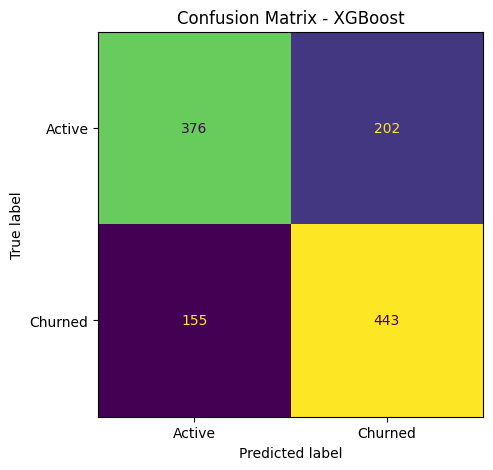

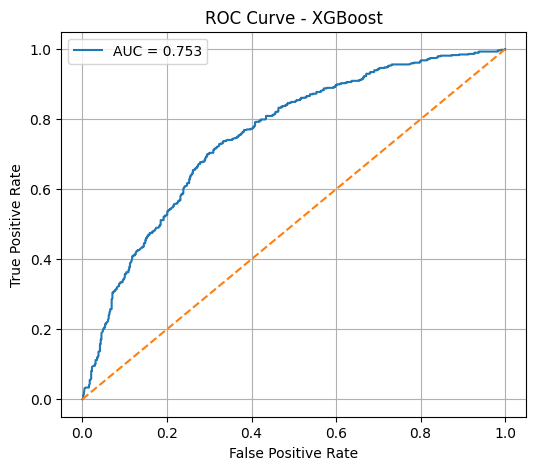

🏃 View run XGBoost_Churn at: http://localhost:5000/#/experiments/2/runs/6649adb02ffe42548e813b3c795ab667
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [8]:

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt

mlflow.end_run()

with mlflow.start_run(run_name="XGBoost_Churn"):

    # Model
    model = XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    # Metrics
    auc_score = roc_auc_score(y_test, y_pred_proba)
    accuracy = (y_pred == y_test).mean() * 100

    # MLflow Logging
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("learning_rate", 0.05)

    mlflow.log_metric("AUC_ROC", round(auc_score, 4))
    mlflow.log_metric("Accuracy", round(accuracy, 2))

    # Print
    print("=" * 50)
    print("Churn Model - XGBoost Results")
    print("=" * 50)
    print(f"AUC-ROC : {auc_score:.4f} (Target >= 0.80)")
    print(f"Accuracy: {accuracy:.1f}%")
    print("=" * 50)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

    # ==============================
    # Confusion Matrix
    # ==============================

    fig, ax = plt.subplots(figsize=(6,5))
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Active', 'Churned']
    )

    disp.plot(ax=ax, colorbar=False)
    ax.set_title("Confusion Matrix - XGBoost")

    plt.show()

    # ==============================
    # ROC Curve
    # ==============================

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - XGBoost")
    plt.legend()
    plt.grid()

    plt.show()

In [12]:
importance =pd.DataFrame({
    'feature':feature_cols,
    'importance':model.feature_importances_
}).sort_values(by="importance",ascending=False)

print(importance)

           feature  importance
0        frequency    0.411681
2          f_score    0.269231
4  avg_order_value    0.108389
1     monetary_log    0.107650
3          m_score    0.103049


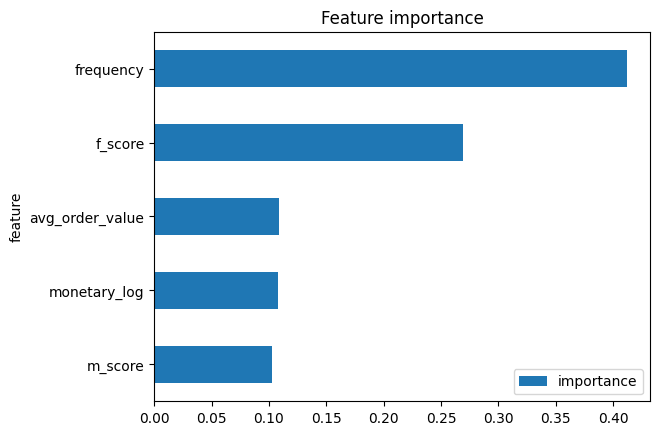

In [13]:
importance.head(10).plot(
    x='feature',
    y='importance',
    kind='barh'
)
plt.title('Feature importance')
plt.gca().invert_yaxis()
plt.show()

# LightGBM model

In [9]:
from lightgbm import LGBMClassifier

mlflow.end_run()

with mlflow.start_run(run_name="LightGBM_Churn"):

    lgb_model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

    lgb_model.fit(X_train, y_train)

    lgb_preds = lgb_model.predict(X_test)
    lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

    from sklearn.metrics import roc_auc_score

    lgb_auc = roc_auc_score(y_test, lgb_proba)
    lgb_acc = (lgb_preds == y_test).mean() * 100

    print("LightGBM AUC:", round(lgb_auc, 4))
    print("LightGBM Accuracy:", round(lgb_acc, 2))

[LightGBM] [Info] Number of positive: 2391, number of negative: 2311
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 581
[LightGBM] [Info] Number of data points in the train set: 4702, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508507 -> initscore=0.034031
[LightGBM] [Info] Start training from score 0.034031
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [10]:
# Ensemble (XGB + LGB)

xgb_proba = model.predict_proba(X_test)[:, 1]

final_proba = 0.5 * xgb_proba + 0.5 * lgb_proba
final_preds = (final_proba > 0.5).astype(int)

from sklearn.metrics import roc_auc_score, accuracy_score

ensemble_auc = roc_auc_score(y_test, final_proba)
ensemble_acc = accuracy_score(y_test, final_preds) * 100

print("ENSEMBLE AUC:", round(ensemble_auc, 4))
print("ENSEMBLE Accuracy:", round(ensemble_acc, 2))

ENSEMBLE AUC: 0.7523
ENSEMBLE Accuracy: 69.64


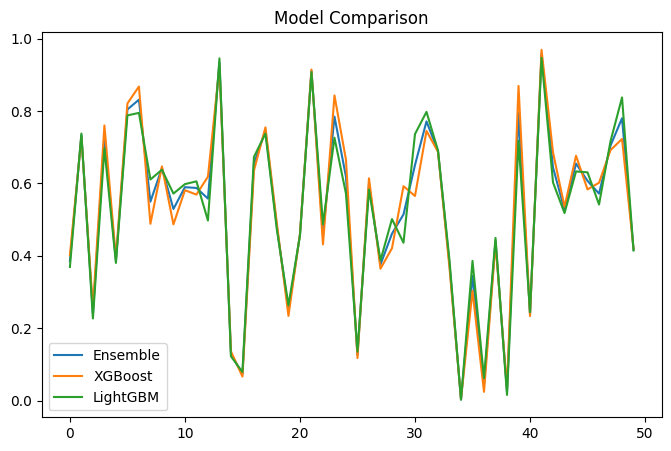

In [11]:
plt.figure(figsize=(8,5))
plt.plot(final_proba[:50], label="Ensemble")
plt.plot(xgb_proba[:50], label="XGBoost")
plt.plot(lgb_proba[:50], label="LightGBM")

plt.legend()
plt.title("Model Comparison")
plt.show()